# Black Grouse 2030 Land-Use Scenario Project

## Stage 12: Multi-Objective Scenario Assessment

This notebook integrates the ecological, economic and social indicators generated in the preceding stages.

The assessment will:

- Combine habitat configuration, restoration suitability and connectivity indicators.
- Include agricultural opportunity costs from Stage 10.
- Include population accessibility and recreational-disturbance indicators from Stage 11.
- Standardise indicators to a common 0–1 scale.
- Compare the four restoration scenarios under alternative policy-priority contexts.
- Test how scenario rankings change when indicator weights change.

No new restoration scenarios or external spatial datasets are introduced in this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "data").exists():
    if (PROJECT_DIR.parent / "data").exists():
        PROJECT_DIR = PROJECT_DIR.parent
    else:
        raise FileNotFoundError(
            "The project directory could not be found."
        )

TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Input tables
# ---------------------------------------------------------

ECOLOGICAL_PATH = (
    TABLES_DIR
    / "2030_scenario_comparison_complete.csv"
)

ECONOMIC_PATH = (
    TABLES_DIR
    / "scenario_economic_cost_ranking.csv"
)

SOCIAL_PATH = (
    TABLES_DIR
    / "scenario_social_access_recreation_summary.csv"
)

required_files = {
    "Ecological comparison": ECOLOGICAL_PATH,
    "Economic costs": ECONOMIC_PATH,
    "Social accessibility": SOCIAL_PATH,
}

missing_files = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            f"- {name}: {path}"
            for name, path in missing_files.items()
        )
    )

print("All Notebook 12 input tables were found.")


# ---------------------------------------------------------
# Load tables
# ---------------------------------------------------------

ecological = pd.read_csv(ECOLOGICAL_PATH)
economic = pd.read_csv(ECONOMIC_PATH)
social = pd.read_csv(SOCIAL_PATH)


print("\nTable dimensions:")
print(f"Ecological: {ecological.shape}")
print(f"Economic:   {economic.shape}")
print(f"Social:     {social.shape}")


# ---------------------------------------------------------
# Inspect scenario names
# ---------------------------------------------------------

for table_name, table in {
    "Ecological": ecological,
    "Economic": economic,
    "Social": social,
}.items():

    if "scenario" not in table.columns:
        raise ValueError(
            f"{table_name} table has no 'scenario' column."
        )

    print(f"\n{table_name} scenarios:")
    print(table["scenario"].tolist())


# ---------------------------------------------------------
# Display ecological columns
# ---------------------------------------------------------

print("\nEcological-table columns:")

for column in ecological.columns:
    print(f"- {column}")


candidate_ecological_columns = [
    column
    for column in ecological.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "patch",
            "edge",
            "connect",
            "component",
            "suitability",
            "distance",
            "habitat",
            "urban",
        ]
    )
]

print("\nLikely ecological indicators:")

for column in candidate_ecological_columns:
    print(f"- {column}")


display(ecological)
display(economic)
display(social)

All Notebook 12 input tables were found.

Table dimensions:
Ecological: (5, 37)
Economic:   (4, 6)
Social:     (4, 14)

Ecological scenarios:
['baseline_2024', 'dispersed', 'patch_enlargement', 'connectivity_focused', 'integrated_low_matrix_pressure']

Economic scenarios:
['Patch enlargement', 'Dispersed', 'Integrated', 'Connectivity focused']

Social scenarios:
['Dispersed', 'Patch enlargement', 'Connectivity focused', 'Integrated']

Ecological-table columns:
- scenario
- core_habitat_area_km2
- number_of_patches
- patch_density_per_100_km2
- mean_patch_area_km2
- median_patch_area_km2
- largest_patch_area_km2
- largest_patch_index_percent
- total_edge_length_km
- edge_density_m_per_ha
- network_component_count_0m
- network_component_count_100m
- network_component_count_250m
- network_component_count_500m
- network_component_count_1000m
- isolated_patch_percentage_0m
- isolated_patch_percentage_100m
- isolated_patch_percentage_250m
- isolated_patch_percentage_500m
- isolated_patch_per

,scenario,core_habitat_area_km2,number_of_patches,patch_density_per_100_km2,mean_patch_area_km2,median_patch_area_km2,largest_patch_area_km2,largest_patch_index_percent,total_edge_length_km,edge_density_m_per_ha,...,largest_component_habitat_percent_250m,largest_component_habitat_percent_500m,largest_component_habitat_percent_1000m,restored_pixels,restored_area_km2,mean_distance_to_core_m,mean_distance_to_urban_m,mean_surrounding_core,mean_surrounding_urban,mean_suitability_score
0,baseline_2024,54.408,2570,336.883,0.0212,0.0012,13.093,1.716,1497.675,19.632,...,28.17,53.02,98.29,0,0.000,NaN,NaN,NaN,NaN,NaN
1,dispersed,66.063,19058,2498.181,0.0035,0.0006,13.101,1.717,3296.400,43.210,...,99.42,99.99,100.00,18649,11.656,371.65,115.62,0.0393,0.1094,0.4675
2,patch_enlargement,66.063,2290,300.180,0.0288,0.0031,13.418,1.759,1789.775,23.461,...,36.48,50.61,97.77,18649,11.656,31.11,149.93,0.1229,0.0806,0.6748
3,connectivity_focused,66.063,2546,333.738,0.0259,0.0012,14.749,1.933,1633.425,21.411,...,47.76,53.54,98.59,18649,11.656,119.53,142.50,0.2865,0.0787,0.7783
4,integrated_low_matrix_pressure,66.063,2574,337.408,0.0257,0.0012,13.878,1.819,1664.625,21.820,...,44.27,51.17,98.58,18649,11.656,123.22,255.78,0.2261,0.0539,0.8382


,rank_lowest_cost,scenario,restored_area_ha,brp_coverage_percent,annual_output_displaced_euro,output_displaced_per_restored_ha_euro
0,1,Patch enlargement,1165.56,77.75,1569796.56,1346.81
1,2,Dispersed,1165.56,87.68,1847400.57,1584.99
2,3,Integrated,1165.56,92.32,2246921.42,1927.76
3,4,Connectivity focused,1165.56,84.87,2252302.79,1932.37


,scenario,population_within_2km_estimate,population_within_5km_estimate,population_within_10km_estimate,population_weighted_mean_distance_m,restoration_within_250m_percent,restoration_within_500m_percent,restoration_within_1000m_percent,potential_parking_access_within_500m,potential_parking_access_within_1000m,population_access_rank,population_distance_rank,network_access_rank,lowest_disturbance_rank
0,Dispersed,200377,328588,524337,3980.2,35.66,65.94,92.28,215,312,1,1,4,1
1,Patch enlargement,172393,310671,520876,4375.9,48.20,77.90,96.52,70,175,2,2,2,4
2,Connectivity focused,66331,178859,348230,8067.7,44.59,79.04,99.74,9,33,4,4,1,3
3,Integrated,87184,232153,476842,5739.7,41.87,76.52,99.55,10,38,3,3,3,2


In [2]:
# ---------------------------------------------------------
# Standardise scenario names
# ---------------------------------------------------------

scenario_name_map = {
    "dispersed": "Dispersed",
    "patch_enlargement": "Patch enlargement",
    "connectivity_focused": "Connectivity focused",
    "integrated_low_matrix_pressure": "Integrated",
}

ecological_scenarios = (
    ecological[
        ecological["scenario"] != "baseline_2024"
    ]
    .copy()
)

ecological_scenarios["scenario"] = (
    ecological_scenarios["scenario"]
    .map(scenario_name_map)
)

if ecological_scenarios["scenario"].isna().any():
    raise ValueError(
        "At least one ecological scenario name could not be mapped."
    )


# ---------------------------------------------------------
# Select indicators
# ---------------------------------------------------------

ecological_selected = ecological_scenarios[
    [
        "scenario",
        "mean_patch_area_km2",
        "edge_density_m_per_ha",
        "largest_component_habitat_percent_250m",
        "mean_suitability_score",
    ]
].copy()

economic_selected = economic[
    [
        "scenario",
        "annual_output_displaced_euro",
    ]
].copy()

social_selected = social[
    [
        "scenario",
        "population_within_5km_estimate",
        "restoration_within_500m_percent",
        "restoration_within_250m_percent",
    ]
].copy()


# ---------------------------------------------------------
# Merge ecological, economic and social results
# ---------------------------------------------------------

assessment = (
    ecological_selected
    .merge(
        economic_selected,
        on="scenario",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        social_selected,
        on="scenario",
        how="inner",
        validate="one_to_one",
    )
)

if len(assessment) != 4:
    raise ValueError(
        "The integrated assessment must contain four scenarios."
    )

if assessment.isna().any().any():
    raise ValueError(
        "The integrated assessment contains missing values."
    )


# ---------------------------------------------------------
# Min-max standardisation
# ---------------------------------------------------------

def min_max_positive(series):
    """
    Higher original values receive higher standardised scores.
    """
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            1.0,
            index=series.index,
        )

    return (
        (series - minimum)
        / (maximum - minimum)
    )


def min_max_negative(series):
    """
    Lower original values receive higher standardised scores.
    """
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            1.0,
            index=series.index,
        )

    return (
        (maximum - series)
        / (maximum - minimum)
    )


# Positive ecological indicators
assessment["score_mean_patch_area"] = (
    min_max_positive(
        assessment["mean_patch_area_km2"]
    )
)

assessment["score_connectivity_250m"] = (
    min_max_positive(
        assessment[
            "largest_component_habitat_percent_250m"
        ]
    )
)

assessment["score_restoration_suitability"] = (
    min_max_positive(
        assessment["mean_suitability_score"]
    )
)

# Lower edge density is preferred
assessment["score_low_edge_density"] = (
    min_max_negative(
        assessment["edge_density_m_per_ha"]
    )
)

# Lower agricultural output displacement is preferred
assessment["score_low_economic_cost"] = (
    min_max_negative(
        assessment[
            "annual_output_displaced_euro"
        ]
    )
)

# Greater population and network access are preferred
assessment["score_population_access"] = (
    min_max_positive(
        assessment[
            "population_within_5km_estimate"
        ]
    )
)

assessment["score_recreation_access"] = (
    min_max_positive(
        assessment[
            "restoration_within_500m_percent"
        ]
    )
)

# Lower close-range recreation exposure is preferred
assessment["score_low_disturbance"] = (
    min_max_negative(
        assessment[
            "restoration_within_250m_percent"
        ]
    )
)


# ---------------------------------------------------------
# Create dimension scores
# ---------------------------------------------------------

assessment["ecological_score"] = assessment[
    [
        "score_mean_patch_area",
        "score_low_edge_density",
        "score_connectivity_250m",
        "score_restoration_suitability",
    ]
].mean(axis=1)

assessment["economic_score"] = (
    assessment["score_low_economic_cost"]
)

assessment["social_access_score"] = assessment[
    [
        "score_population_access",
        "score_recreation_access",
    ]
].mean(axis=1)

assessment["low_disturbance_score"] = (
    assessment["score_low_disturbance"]
)


dimension_columns = [
    "ecological_score",
    "economic_score",
    "social_access_score",
    "low_disturbance_score",
]

assessment[dimension_columns] = (
    assessment[dimension_columns]
    .round(4)
)


# ---------------------------------------------------------
# Validate score ranges
# ---------------------------------------------------------

for column in dimension_columns:

    if not assessment[column].between(
        0,
        1,
        inclusive="both",
    ).all():
        raise ValueError(
            f"{column} contains values outside 0–1."
        )


dimension_scores = assessment[
    [
        "scenario",
        *dimension_columns,
    ]
].copy()

display(dimension_scores)

,scenario,ecological_score,economic_score,social_access_score,low_disturbance_score
0,Dispersed,0.2500,0.5933,0.5000,1.0000
1,Patch enlargement,0.6163,1.0000,0.8967,0.0000
2,Connectivity focused,0.7258,0.0000,0.5000,0.2879
3,Integrated,0.7456,0.0079,0.5818,0.5048


In [3]:
# ---------------------------------------------------------
# Define policy-context weights
# ---------------------------------------------------------

policy_weights = pd.DataFrame(
    [
        {
            "policy_context": "Nature priority",
            "ecological_score": 0.55,
            "economic_score": 0.10,
            "social_access_score": 0.10,
            "low_disturbance_score": 0.25,
        },
        {
            "policy_context": "Multifunctional",
            "ecological_score": 0.35,
            "economic_score": 0.25,
            "social_access_score": 0.25,
            "low_disturbance_score": 0.15,
        },
        {
            "policy_context": "Production oriented",
            "ecological_score": 0.20,
            "economic_score": 0.50,
            "social_access_score": 0.20,
            "low_disturbance_score": 0.10,
        },
    ]
)


# ---------------------------------------------------------
# Validate weights
# ---------------------------------------------------------

weight_columns = [
    "ecological_score",
    "economic_score",
    "social_access_score",
    "low_disturbance_score",
]

policy_weights["weight_sum"] = (
    policy_weights[weight_columns].sum(axis=1)
)

if not np.allclose(
    policy_weights["weight_sum"],
    1.0,
):
    raise ValueError(
        "Policy-context weights must sum to 1."
    )


# ---------------------------------------------------------
# Calculate weighted policy scores
# ---------------------------------------------------------

policy_results = []

for _, policy_row in policy_weights.iterrows():

    context_name = policy_row[
        "policy_context"
    ]

    context_scores = dimension_scores.copy()

    context_scores[
        "policy_context"
    ] = context_name

    context_scores[
        "weighted_score"
    ] = (
        context_scores["ecological_score"]
        * policy_row["ecological_score"]
        +
        context_scores["economic_score"]
        * policy_row["economic_score"]
        +
        context_scores["social_access_score"]
        * policy_row["social_access_score"]
        +
        context_scores["low_disturbance_score"]
        * policy_row["low_disturbance_score"]
    )

    context_scores["rank"] = (
        context_scores["weighted_score"]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

    policy_results.append(
        context_scores
    )


policy_rankings = pd.concat(
    policy_results,
    ignore_index=True,
)

policy_rankings["weighted_score"] = (
    policy_rankings["weighted_score"]
    .round(4)
)


# ---------------------------------------------------------
# Create compact comparison table
# ---------------------------------------------------------

policy_score_table = (
    policy_rankings
    .pivot(
        index="scenario",
        columns="policy_context",
        values="weighted_score",
    )
    .reset_index()
)

policy_rank_table = (
    policy_rankings
    .pivot(
        index="scenario",
        columns="policy_context",
        values="rank",
    )
    .reset_index()
)

policy_score_table.columns.name = None
policy_rank_table.columns.name = None


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

WEIGHTS_PATH = (
    TABLES_DIR
    / "policy_context_weights.csv"
)

POLICY_RESULTS_PATH = (
    TABLES_DIR
    / "scenario_policy_context_rankings.csv"
)

DIMENSION_SCORES_PATH = (
    TABLES_DIR
    / "scenario_dimension_scores.csv"
)

policy_weights.drop(
    columns="weight_sum"
).to_csv(
    WEIGHTS_PATH,
    index=False,
)

policy_rankings.to_csv(
    POLICY_RESULTS_PATH,
    index=False,
)

dimension_scores.to_csv(
    DIMENSION_SCORES_PATH,
    index=False,
)


print("Policy-context scores:")
display(policy_score_table)

print("\nPolicy-context ranks:")
display(policy_rank_table)

print("\nOutputs saved:")
print(f"- {WEIGHTS_PATH}")
print(f"- {POLICY_RESULTS_PATH}")
print(f"- {DIMENSION_SCORES_PATH}")

Policy-context scores:


,scenario,Multifunctional,Nature priority,Production oriented
0,Connectivity focused,0.4222,0.5212,0.2740
1,Dispersed,0.5108,0.4968,0.5466
2,Integrated,0.4841,0.5953,0.3199
3,Patch enlargement,0.6899,0.5286,0.8026



Policy-context ranks:


,scenario,Multifunctional,Nature priority,Production oriented
0,Connectivity focused,4,3,4
1,Dispersed,2,4,2
2,Integrated,3,1,3
3,Patch enlargement,1,2,1



Outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\policy_context_weights.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_policy_context_rankings.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_dimension_scores.csv


Weight-sensitivity results:


,scenario,times_ranked_first,first_place_percent,mean_simulated_score,mean_simulated_rank,top_two_percent
0,Patch enlargement,5720,57.20,0.63,1.78,76.09
1,Dispersed,3444,34.44,0.59,2.08,74.47
2,Integrated,836,8.36,0.46,2.46,46.06
3,Connectivity focused,0,0.00,0.38,3.68,3.38



Final multi-objective assessment:


,scenario,ecological_score,economic_score,social_access_score,low_disturbance_score,Multifunctional_score,Nature priority_score,Production oriented_score,Multifunctional_rank,Nature priority_rank,Production oriented_rank,times_ranked_first,first_place_percent,mean_simulated_score,mean_simulated_rank,top_two_percent
0,Dispersed,0.2500,0.5933,0.5000,1.0000,0.5108,0.4968,0.5466,2,4,2,3444,34.44,0.59,2.08,74.47
1,Patch enlargement,0.6163,1.0000,0.8967,0.0000,0.6899,0.5286,0.8026,1,2,1,5720,57.20,0.63,1.78,76.09
2,Connectivity focused,0.7258,0.0000,0.5000,0.2879,0.4222,0.5212,0.2740,4,3,4,0,0.00,0.38,3.68,3.38
3,Integrated,0.7456,0.0079,0.5818,0.5048,0.4841,0.5953,0.3199,3,1,3,836,8.36,0.46,2.46,46.06


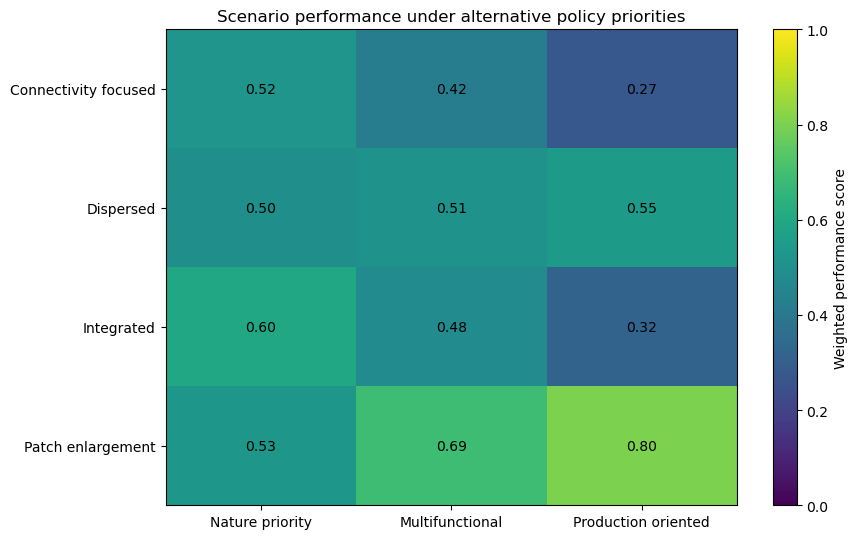

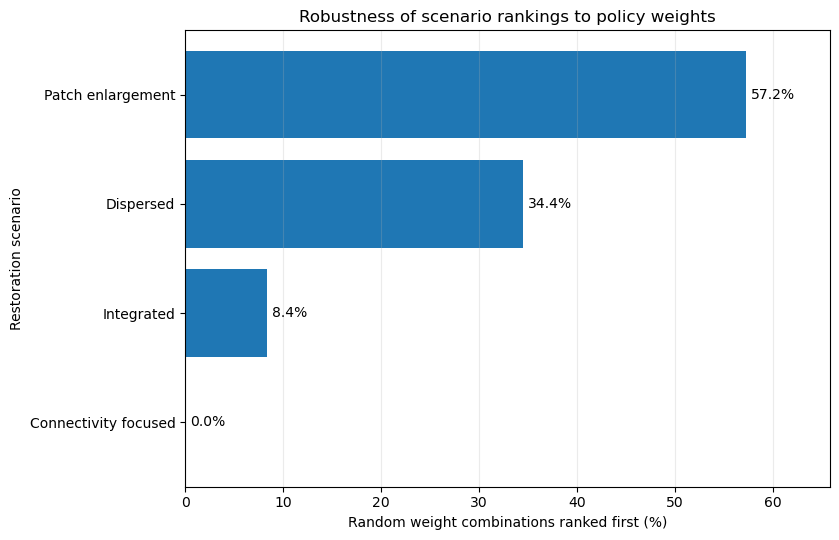


Notebook 12 final validation passed.

Final outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_weight_sensitivity.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\final_multiobjective_scenario_assessment.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\figures\scenario_policy_context_comparison.png
- C:\Users\smit1\BlackGrouse_2030\outputs\figures\scenario_weight_sensitivity.png


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Weight-sensitivity analysis
dimension_names = [
    "ecological_score",
    "economic_score",
    "social_access_score",
    "low_disturbance_score",
]

scenario_names = dimension_scores["scenario"].tolist()

score_matrix = dimension_scores[
    dimension_names
].to_numpy(dtype=float)

rng = np.random.default_rng(42)
number_of_simulations = 10_000

random_weights = rng.dirichlet(
    np.ones(len(dimension_names)),
    size=number_of_simulations,
)

# Rows are scenarios; columns are simulations
simulated_scores = score_matrix @ random_weights.T

winner_indices = np.argmax(simulated_scores, axis=0)

winner_counts = np.bincount(
    winner_indices,
    minlength=len(scenario_names),
)


# Calculate rank of every scenario in every simulation
scenario_order = np.argsort(
    -simulated_scores,
    axis=0,
)

simulated_ranks = np.empty_like(
    scenario_order,
    dtype=int,
)

simulation_indices = np.arange(
    number_of_simulations
)

for rank_position in range(len(scenario_names)):
    simulated_ranks[
        scenario_order[rank_position, :],
        simulation_indices,
    ] = rank_position + 1


# Create sensitivity summary
sensitivity_summary = pd.DataFrame(
    {
        "scenario": scenario_names,
        "times_ranked_first": winner_counts,
        "first_place_percent": (
            winner_counts
            / number_of_simulations
            * 100
        ),
        "mean_simulated_score": (
            simulated_scores.mean(axis=1)
        ),
        "mean_simulated_rank": (
            simulated_ranks.mean(axis=1)
        ),
        "top_two_percent": (
            (simulated_ranks <= 2).mean(axis=1)
            * 100
        ),
    }
)

columns_to_round = [
    "first_place_percent",
    "mean_simulated_score",
    "mean_simulated_rank",
    "top_two_percent",
]

sensitivity_summary[columns_to_round] = (
    sensitivity_summary[columns_to_round]
    .round(2)
)

sensitivity_summary = (
    sensitivity_summary
    .sort_values(
        [
            "first_place_percent",
            "mean_simulated_rank",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)


# Create final integrated assessment table
final_assessment = (
    dimension_scores
    .merge(
        policy_score_table,
        on="scenario",
        how="left",
        validate="one_to_one",
    )
    .merge(
        policy_rank_table,
        on="scenario",
        how="left",
        validate="one_to_one",
        suffixes=("_score", "_rank"),
    )
    .merge(
        sensitivity_summary,
        on="scenario",
        how="left",
        validate="one_to_one",
    )
)

if len(final_assessment) != 4:
    raise ValueError(
        "The final assessment must contain four scenarios."
    )

if final_assessment.isna().any().any():
    raise ValueError(
        "The final assessment contains missing values."
    )


# Save final tables
SENSITIVITY_PATH = (
    TABLES_DIR
    / "scenario_weight_sensitivity.csv"
)

FINAL_ASSESSMENT_PATH = (
    TABLES_DIR
    / "final_multiobjective_scenario_assessment.csv"
)

sensitivity_summary.to_csv(
    SENSITIVITY_PATH,
    index=False,
)

final_assessment.to_csv(
    FINAL_ASSESSMENT_PATH,
    index=False,
)

print("Weight-sensitivity results:")
display(sensitivity_summary)

print("\nFinal multi-objective assessment:")
display(final_assessment)


# Figure 1: Policy-context scores
policy_plot = (
    policy_score_table
    .set_index("scenario")
)

policy_plot = policy_plot[
    [
        "Nature priority",
        "Multifunctional",
        "Production oriented",
    ]
]

fig, ax = plt.subplots(figsize=(9, 5.5))

heatmap = ax.imshow(
    policy_plot.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    np.arange(len(policy_plot.columns))
)

ax.set_xticklabels(
    policy_plot.columns
)

ax.set_yticks(
    np.arange(len(policy_plot.index))
)

ax.set_yticklabels(
    policy_plot.index
)

ax.set_title(
    "Scenario performance under alternative policy priorities"
)

for row_index in range(len(policy_plot.index)):
    for column_index in range(
        len(policy_plot.columns)
    ):
        value = policy_plot.iloc[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
        )

colorbar = fig.colorbar(
    heatmap,
    ax=ax,
)

colorbar.set_label(
    "Weighted performance score"
)

plt.tight_layout()

POLICY_FIGURE_PATH = (
    FIGURES_DIR
    / "scenario_policy_context_comparison.png"
)

plt.savefig(
    POLICY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 2: Sensitivity results
robustness_plot = (
    sensitivity_summary
    .sort_values(
        "first_place_percent",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars = ax.barh(
    robustness_plot["scenario"],
    robustness_plot["first_place_percent"],
)

ax.set_xlabel(
    "Random weight combinations ranked first (%)"
)

ax.set_ylabel(
    "Restoration scenario"
)

ax.set_title(
    "Robustness of scenario rankings to policy weights"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

for bar, value in zip(
    bars,
    robustness_plot["first_place_percent"],
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
    )

ax.set_xlim(
    0,
    max(
        robustness_plot[
            "first_place_percent"
        ].max() * 1.15,
        5,
    ),
)

plt.tight_layout()

SENSITIVITY_FIGURE_PATH = (
    FIGURES_DIR
    / "scenario_weight_sensitivity.png"
)

plt.savefig(
    SENSITIVITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nNotebook 12 final validation passed.")

print("\nFinal outputs saved:")
print(f"- {SENSITIVITY_PATH}")
print(f"- {FINAL_ASSESSMENT_PATH}")
print(f"- {POLICY_FIGURE_PATH}")
print(f"- {SENSITIVITY_FIGURE_PATH}")